In [1]:
import os
from os import listdir
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import plotly.express as px
import seaborn as sns

import cv2
from matplotlib.image import imread

#import tensorflow as tf
#from keras.utils.np_utils import to_categorical
#from keras.preprocessing import image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix


import glob
import PIL
import random

random.seed(100)

In [2]:
image_dir = "/scratch/xxsi3290/Kaggle/jpeg/jpeg/"

In [3]:
dicom_data = pd.read_csv('/scratch/xxsi3290/Kaggle/dicom_info.csv')
dicom_data.head()

,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0
3,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,16,16,BREAST,97,20160503,115347.770,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,32298,ISO_IR 100,20170829.0,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,180109.0
4,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.38118...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...,NaN,8,8,Left Breast,3104,20160503,115347.770,WSD,...,MATLAB,NaN,1.3.6.1.4.1.9590.100.1.2.381187369611524586537...,1,0,ISO_IR 100,NaN,DDSM,1.3.6.1.4.1.9590.100.1.2.335006093711888937440...,NaN


In [4]:
dicom_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10237 entries, 0 to 10236
Data columns (total 38 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   file_path                                    10237 non-null  object 
 1   image_path                                   10237 non-null  object 
 2   AccessionNumber                              0 non-null      float64
 3   BitsAllocated                                10237 non-null  int64  
 4   BitsStored                                   10237 non-null  int64  
 5   BodyPartExamined                             10237 non-null  object 
 6   Columns                                      10237 non-null  int64  
 7   ContentDate                                  10237 non-null  int64  
 8   ContentTime                                  10237 non-null  float64
 9   ConversionType                               10237 non-null  object 
 10

In [5]:
# check image types in dataset
dicom_data.SeriesDescription.unique()

array(['cropped images', 'full mammogram images', nan, 'ROI mask images'],
      dtype=object)

In [6]:
meta_data = pd.read_csv('/scratch/xxsi3290/Kaggle/meta.csv')
meta_data.head()

,SeriesInstanceUID,StudyInstanceUID,Modality,SeriesDescription,BodyPartExamined,SeriesNumber,Collection,Visibility,ImageCount
0,1.3.6.1.4.1.9590.100.1.2.117041576511324414842...,1.3.6.1.4.1.9590.100.1.2.229361142710768138411...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
1,1.3.6.1.4.1.9590.100.1.2.438738396107617880132...,1.3.6.1.4.1.9590.100.1.2.195593486612988388325...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
2,1.3.6.1.4.1.9590.100.1.2.767416741131676463382...,1.3.6.1.4.1.9590.100.1.2.257901172612530623323...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
3,1.3.6.1.4.1.9590.100.1.2.296931352612305599800...,1.3.6.1.4.1.9590.100.1.2.109468616710242115222...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2
4,1.3.6.1.4.1.9590.100.1.2.436657670120353100077...,1.3.6.1.4.1.9590.100.1.2.380627129513562450304...,MG,ROI mask images,BREAST,1,CBIS-DDSM,1,2


In [7]:
meta_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6775 entries, 0 to 6774
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   SeriesInstanceUID  6775 non-null   object
 1   StudyInstanceUID   6775 non-null   object
 2   Modality           6775 non-null   object
 3   SeriesDescription  6775 non-null   object
 4   BodyPartExamined   6775 non-null   object
 5   SeriesNumber       6775 non-null   int64 
 6   Collection         6775 non-null   object
 7   Visibility         6775 non-null   int64 
 8   ImageCount         6775 non-null   int64 
dtypes: int64(3), object(6)
memory usage: 476.5+ KB


In [8]:
cropped_images = dicom_data[dicom_data.SeriesDescription == 'cropped images'].image_path
cropped_images.head()

0     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...
3     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.381187...
6     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...
7     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994...
10    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.411833...
Name: image_path, dtype: object

In [9]:
full_mammogram_images = dicom_data[dicom_data.SeriesDescription == 'full mammogram images'].image_path
full_mammogram_images.head()

1     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...
2     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...
11    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.210396...
12    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.749566...
15    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.987658...
Name: image_path, dtype: object

In [10]:
ROI_mask_images = dicom_data[dicom_data.SeriesDescription == 'ROI mask images'].image_path
ROI_mask_images.head()

5     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.153339...
8     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.178994...
9     CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.411833...
14    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.236373...
20    CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.357008...
Name: image_path, dtype: object

In [11]:
#cropped_images = cropped_images.apply(lambda x: x.replace('CBIS-DDSM/jpeg/', image_dir, regex=True))
cropped_images = cropped_images.replace('CBIS-DDSM/jpeg/', image_dir, regex=True)
#cropped_images.head()

full_mammogram_images = full_mammogram_images.replace('CBIS-DDSM/jpeg/', image_dir, regex=True)
#full_mammogram_images.head()

ROI_mask_images = ROI_mask_images.replace('CBIS-DDSM/jpeg/', image_dir, regex=True)
#ROI_mask_images.head()

# view new paths
print('Cropped Images paths:\n')
print(cropped_images.iloc[0])
print('Full mammo Images paths:\n')
print(full_mammogram_images.iloc[0])
print('ROI Mask Images paths:\n')
print(ROI_mask_images.iloc[0])

Cropped Images paths:

/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg
Full mammo Images paths:

/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg
ROI Mask Images paths:

/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg


In [12]:
# organize image paths
full_mammo_dict = dict()
cropped_images_dict = dict()
roi_img_dict = dict()

for dicom in full_mammogram_images:
    key = dicom.split("/")[6]
    full_mammo_dict[key] = dicom
for dicom in cropped_images:
    key = dicom.split("/")[6]
    cropped_images_dict[key] = dicom
for dicom in ROI_mask_images:
    key = dicom.split("/")[6]
    roi_img_dict[key] = dicom

# view keys
next(iter((full_mammo_dict.items())))

('1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849',
 '/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg')

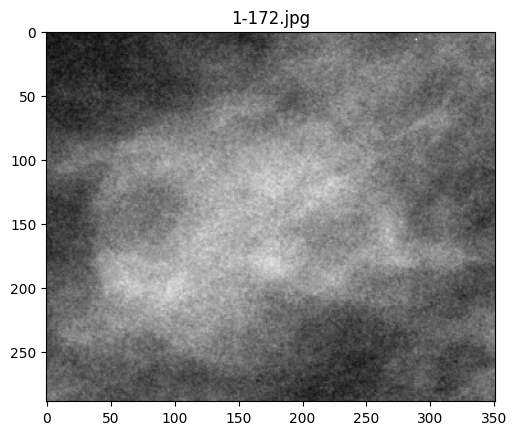

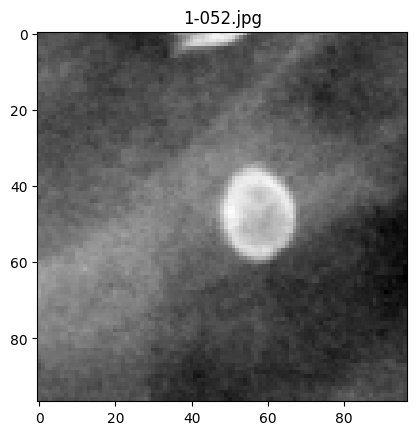

File not found: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/1-034.jpg


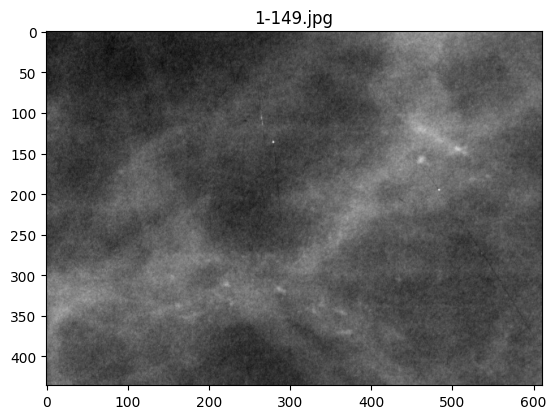

File not found: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.411833492612373627114350673042828631265/1-003.jpg
File not found: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.236373548712994183418851990043419770402/1-085.jpg


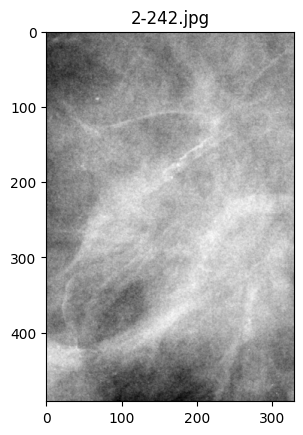

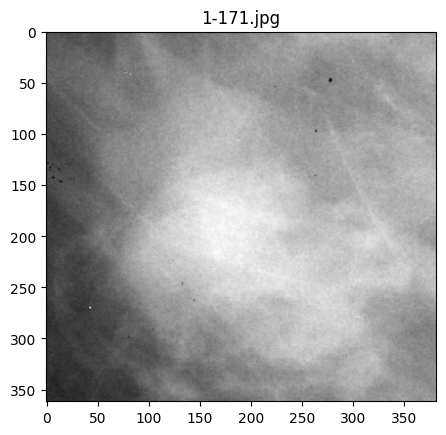

File not found: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.281604745510897859806968805740602385667/1-111.jpg


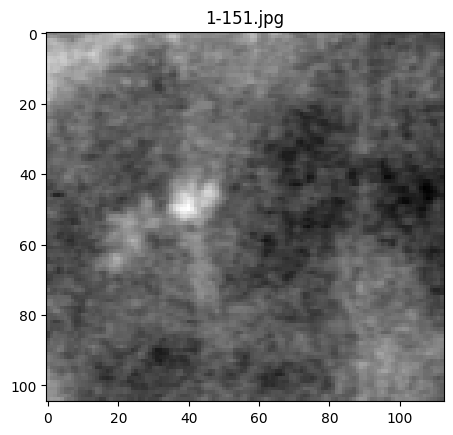

In [13]:
import matplotlib.pyplot as plt 
import glob
import PIL
import random

for file in cropped_images[0:10]:
    try:
        if not os.path.exists(file):
            print(f"File not found: {file}")
            continue  # Skip to the next file
        cropped_images_show = PIL.Image.open(file)
        gray_img = cropped_images_show.convert("L")
        plt.imshow(gray_img, cmap='gray')
        plt.title(os.path.basename(file))
        plt.show()
    except Exception as e:
        print(f"Error loading {file}: {e}")
        continue

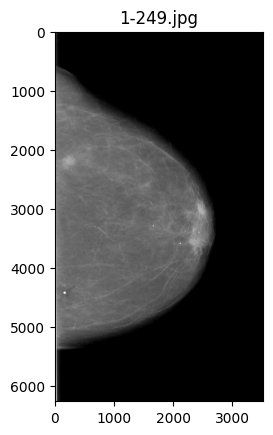

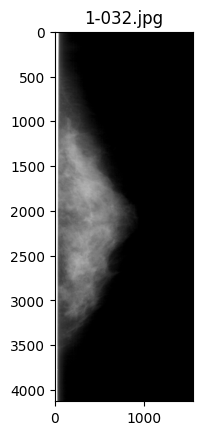

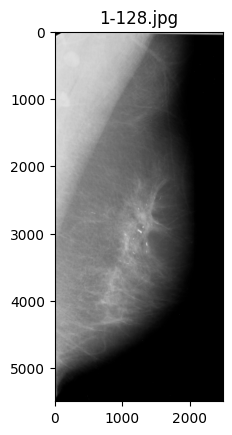

File not found: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.74956658311383957201426978750903861062/1-248.jpg


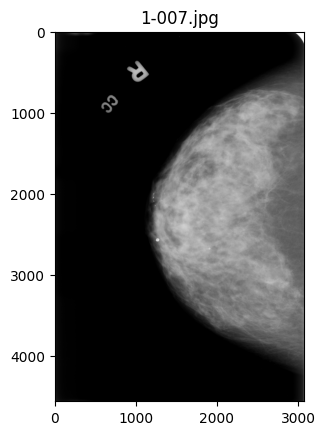

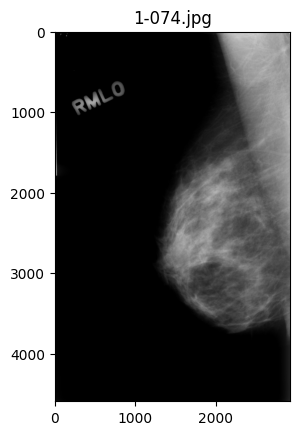

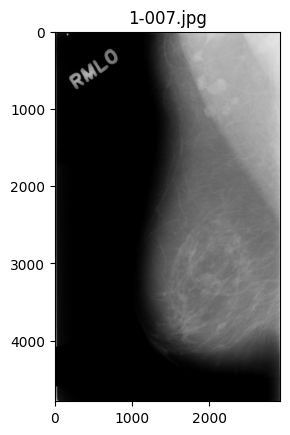

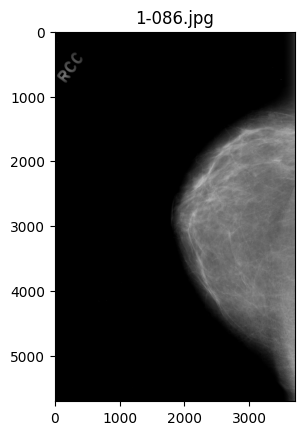

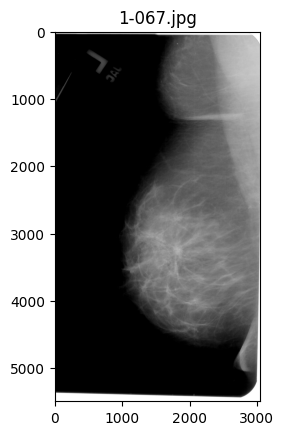

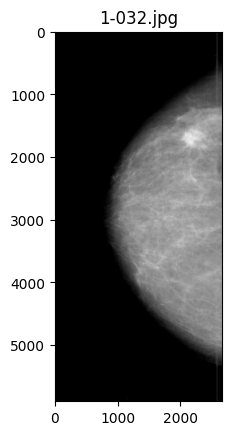

In [14]:
import os
import PIL
import matplotlib.pyplot as plt

for file  in full_mammogram_images[0:10]:
    try:
        if not os.path.exists(file):
            print(f"File not found: {file}")
            continue
        full_mammogram_images_show = PIL.Image.open(file)
        gray_img= full_mammogram_images_show.convert("L")
        plt.imshow(gray_img, cmap='gray')
        plt.title(os.path.basename(file))
        plt.show()
    except Exception as e:
        print(f"Error loading {file}: {e}")
        continue

File not found: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.153339052913121382622526066491844156138/2-270.jpg


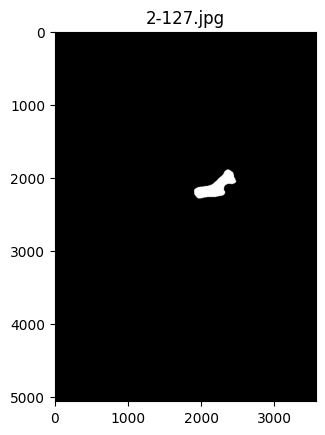

File not found: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.411833492612373627114350673042828631265/2-281.jpg
File not found: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.236373548712994183418851990043419770402/2-086.jpg


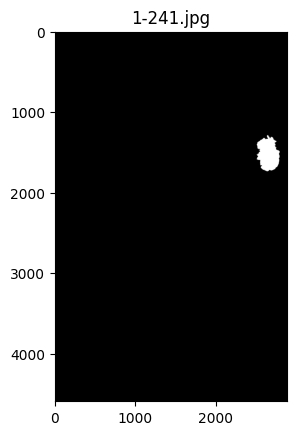

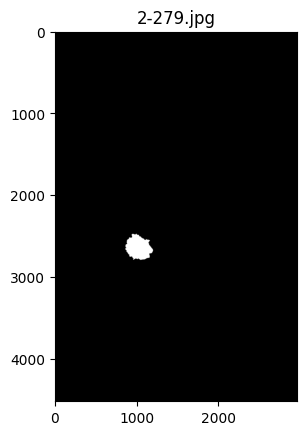

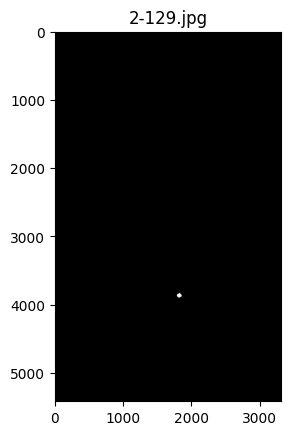

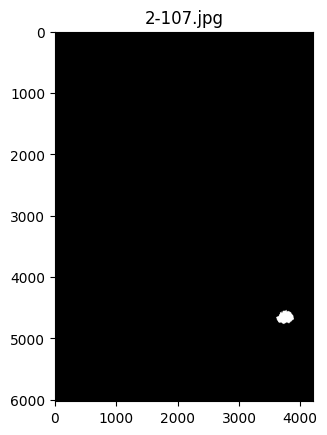

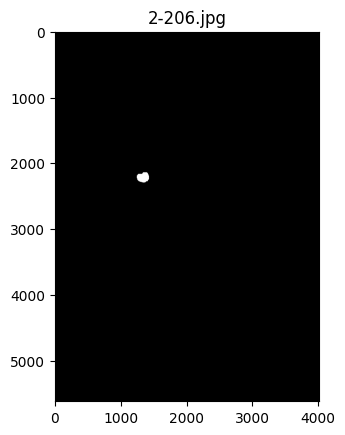

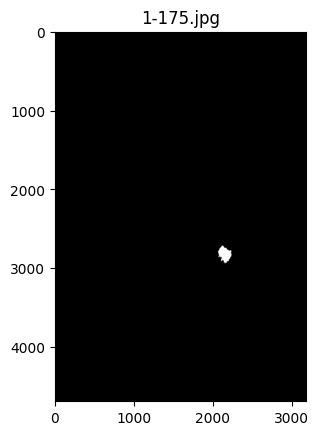

In [15]:
import os
import PIL
import matplotlib.pyplot as plt

for file in ROI_mask_images[0:10]:
    try:
        if not os.path.exists(file):  
            print(f"File not found: {file}")
            continue
        ROI_mask_images_show = PIL.Image.open(file)
        gray_img = ROI_mask_images_show.convert("L")
        plt.imshow(gray_img, cmap='gray')
        plt.title(os.path.basename(file))
        plt.show()
    except Exception as e:
        print(f"Error loading {file}: {e}")
        continue


In [16]:
calc_train_df = pd.read_csv('/scratch/xxsi3290/Kaggle/calc_case_description_train_set.csv')
calc_test_df = pd.read_csv('/scratch/xxsi3290/Kaggle/calc_case_description_test_set.csv')

calc_train_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_CC/1.3.6.1.4.1.959...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...,Calc-Training_P_00005_RIGHT_CC_1/1.3.6.1.4.1.9...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,Calc-Training_P_00005_RIGHT_MLO/1.3.6.1.4.1.95...,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....,Calc-Training_P_00005_RIGHT_MLO_1/1.3.6.1.4.1....
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00007_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,Calc-Training_P_00007_LEFT_MLO/1.3.6.1.4.1.959...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...,Calc-Training_P_00007_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,Calc-Training_P_00008_LEFT_CC/1.3.6.1.4.1.9590...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...,Calc-Training_P_00008_LEFT_CC_1/1.3.6.1.4.1.95...


In [17]:
def fix_image_path_calc(dataset):
    for i, img in enumerate(dataset.values):
        img_name = img[11].split("/")[2]
        if img_name in full_mammo_dict:
            dataset.iloc[i, 11] = full_mammo_dict[img_name]

        img_name = img[12].split("/")[2]
        if img_name in cropped_images_dict:
            dataset.iloc[i, 12] = cropped_images_dict[img_name]
        
        img_name = img[13].split("/")[2]
        if img_name in roi_img_dict:
            dataset.iloc[i, 13] = roi_img_dict[img_name]

fix_image_path_calc(calc_train_df)
fix_image_path_calc(calc_test_df)

In [18]:
# check unique values in pathology column
calc_train_df.pathology.unique()

array(['MALIGNANT', 'BENIGN', 'BENIGN_WITHOUT_CALLBACK'], dtype=object)

In [19]:
calc_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1546 entries, 0 to 1545
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1546 non-null   object
 1   breast density           1546 non-null   int64 
 2   left or right breast     1546 non-null   object
 3   image view               1546 non-null   object
 4   abnormality id           1546 non-null   int64 
 5   abnormality type         1546 non-null   object
 6   calc type                1526 non-null   object
 7   calc distribution        1170 non-null   object
 8   assessment               1546 non-null   int64 
 9   pathology                1546 non-null   object
 10  subtlety                 1546 non-null   int64 
 11  image file path          1546 non-null   object
 12  cropped image file path  1546 non-null   object
 13  ROI mask file path       1546 non-null   object
dtypes: int64(4), object(10)
memory usage: 16

In [20]:
# rename columns
calc_train_df = calc_train_df.rename(columns={'left or right breast': 'left_or_right_breast',
                                           'image view': 'image_view',
                                           'abnormality id': 'abnormality_id',
                                           'abnormality type': 'abnormality_type',
                                           'calc type': 'calc_type',
                                           'calc distribution': 'calc_distribution',
                                           'image file path': 'image_file_path',
                                           'cropped image file path': 'cropped_image_file_path',
                                           'ROI mask file path': 'ROI_mask_file_path'})

calc_train_df.head(5)

,patient_id,breast density,left_or_right_breast,image_view,abnormality_id,abnormality_type,calc_type,calc_distribution,assessment,pathology,subtlety,image_file_path,cropped_image_file_path,ROI_mask_file_path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
4,P_00008,1,LEFT,CC,1,calcification,NaN,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...


In [21]:
calc_train_df.isnull().sum()

patient_id                   0
breast density               0
left_or_right_breast         0
image_view                   0
abnormality_id               0
abnormality_type             0
calc_type                   20
calc_distribution          376
assessment                   0
pathology                    0
subtlety                     0
image_file_path              0
cropped_image_file_path      0
ROI_mask_file_path           0
dtype: int64

In [22]:
# fill in missing values using the backwards fill method
calc_train_df['calc_type'] = calc_train_df['calc_type'].bfill()
calc_train_df['calc_distribution'] = calc_train_df['calc_distribution'].bfill()

#check null values
calc_train_df.isnull().sum()

patient_id                 0
breast density             0
left_or_right_breast       0
image_view                 0
abnormality_id             0
abnormality_type           0
calc_type                  0
calc_distribution          0
assessment                 0
pathology                  0
subtlety                   0
image_file_path            0
cropped_image_file_path    0
ROI_mask_file_path         0
dtype: int64

In [23]:
# quantitative summary of features
calc_train_df.describe()

,breast density,abnormality_id,assessment,subtlety
count,1546.000000,1546.000000,1546.000000,1546.000000
mean,2.663648,1.415265,3.258732,3.411384
std,0.937219,0.903571,1.229231,1.179754
min,1.000000,1.000000,0.000000,1.000000
25%,2.000000,1.000000,2.000000,3.000000
50%,3.000000,1.000000,4.000000,3.000000
75%,3.000000,1.000000,4.000000,4.000000
max,4.000000,7.000000,5.000000,5.000000


In [24]:
calc_test_df.head()

,patient_id,breast density,left or right breast,image view,abnormality id,abnormality type,calc type,calc distribution,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00038,2,LEFT,CC,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_CC/1.3.6.1.4.1.9590.100...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,Calc-Test_P_00038_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00038,2,LEFT,MLO,1,calcification,PUNCTATE-PLEOMORPHIC,CLUSTERED,4,BENIGN,2,Calc-Test_P_00038_LEFT_MLO/1.3.6.1.4.1.9590.10...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,Calc-Test_P_00038_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00038,2,RIGHT,CC,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,Calc-Test_P_00038_RIGHT_CC_1/1.3.6.1.4.1.9590....
3,P_00038,2,RIGHT,CC,2,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_CC/1.3.6.1.4.1.9590.10...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,Calc-Test_P_00038_RIGHT_CC_2/1.3.6.1.4.1.9590....
4,P_00038,2,RIGHT,MLO,1,calcification,VASCULAR,NaN,2,BENIGN_WITHOUT_CALLBACK,5,Calc-Test_P_00038_RIGHT_MLO/1.3.6.1.4.1.9590.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,Calc-Test_P_00038_RIGHT_MLO_1/1.3.6.1.4.1.9590...


In [25]:
# check datasets shape
print(f'Shape of mass_train: {calc_train_df.shape}')
print(f'Shape of mass_test: {calc_test_df.shape}')

Shape of mass_train: (1546, 14)
Shape of mass_test: (326, 14)


In [26]:
calc_test_df = calc_test_df.rename(columns={'left or right breast': 'left_or_right_breast',
                                           'image view': 'image_view',
                                           'abnormality id': 'abnormality_id',
                                           'abnormality type': 'abnormality_type',
                                           'calc type': 'calc_type',
                                           'calc distribution': 'calc_distribution',
                                           'image file path': 'image_file_path',
                                           'cropped image file path': 'cropped_image_file_path',
                                           'ROI mask file path': 'ROI_mask_file_path'})


In [27]:
calc_test_df.isnull().sum()

patient_id                  0
breast density              0
left_or_right_breast        0
image_view                  0
abnormality_id              0
abnormality_type            0
calc_type                   4
calc_distribution          63
assessment                  0
pathology                   0
subtlety                    0
image_file_path             0
cropped_image_file_path     0
ROI_mask_file_path          0
dtype: int64

In [28]:
# fill in missing values using the backwards fill method
calc_test_df['calc_type'] = calc_test_df['calc_type'].bfill()
calc_test_df['calc_distribution'] = calc_test_df['calc_distribution'].bfill()


#check null values
calc_test_df.isnull().sum()

patient_id                 0
breast density             0
left_or_right_breast       0
image_view                 0
abnormality_id             0
abnormality_type           0
calc_type                  0
calc_distribution          0
assessment                 0
pathology                  0
subtlety                   0
image_file_path            0
cropped_image_file_path    0
ROI_mask_file_path         0
dtype: int64

In [29]:
mass_train_df = pd.read_csv('/scratch/xxsi3290/Kaggle/mass_case_description_train_set.csv')
mass_test_df = pd.read_csv('/scratch/xxsi3290/Kaggle/mass_case_description_test_set.csv')

mass_train_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00001_LEFT_CC_1/1.3.6.1.4.1.95...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,Mass-Training_P_00001_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00001_LEFT_MLO_1/1.3.6.1.4.1.9...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_CC/1.3.6.1.4.1.9590...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...,Mass-Training_P_00004_LEFT_CC_1/1.3.6.1.4.1.95...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,Mass-Training_P_00004_LEFT_MLO/1.3.6.1.4.1.959...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...,Mass-Training_P_00004_LEFT_MLO_1/1.3.6.1.4.1.9...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,Mass-Training_P_00004_RIGHT_MLO/1.3.6.1.4.1.95...,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....,Mass-Training_P_00004_RIGHT_MLO_1/1.3.6.1.4.1....


In [30]:
def fix_image_path_mass(dataset):
    for i, img in enumerate(dataset.values):
        img_name = img[11].split("/")[2]
        if img_name in full_mammo_dict:
            dataset.iloc[i, 11] = full_mammo_dict[img_name]

        img_name = img[12].split("/")[2]
        if img_name in cropped_images_dict:
            dataset.iloc[i, 12] = cropped_images_dict[img_name]
        
        img_name = img[13].split("/")[2]
        if img_name in roi_img_dict:
            dataset.iloc[i, 13] = roi_img_dict[img_name]

fix_image_path_mass(mass_train_df)
fix_image_path_mass(mass_test_df)

In [31]:
mass_train_df.pathology.unique()

array(['MALIGNANT', 'BENIGN', 'BENIGN_WITHOUT_CALLBACK'], dtype=object)

In [32]:
mass_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1318 entries, 0 to 1317
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   patient_id               1318 non-null   object
 1   breast_density           1318 non-null   int64 
 2   left or right breast     1318 non-null   object
 3   image view               1318 non-null   object
 4   abnormality id           1318 non-null   int64 
 5   abnormality type         1318 non-null   object
 6   mass shape               1314 non-null   object
 7   mass margins             1275 non-null   object
 8   assessment               1318 non-null   int64 
 9   pathology                1318 non-null   object
 10  subtlety                 1318 non-null   int64 
 11  image file path          1318 non-null   object
 12  cropped image file path  1318 non-null   object
 13  ROI mask file path       1318 non-null   object
dtypes: int64(4), object(10)
memory usage: 14

In [33]:
# rename columns
mass_train_df = mass_train_df.rename(columns={'left or right breast': 'left_or_right_breast',
                                           'image view': 'image_view',
                                           'abnormality id': 'abnormality_id',
                                           'abnormality type': 'abnormality_type',
                                           'mass shape': 'mass_shape',
                                           'mass margins': 'mass_margins',
                                           'image file path': 'image_file_path',
                                           'cropped image file path': 'cropped_image_file_path',
                                           'ROI mask file path': 'ROI_mask_file_path'})

mass_train_df.head(5)

,patient_id,breast_density,left_or_right_breast,image_view,abnormality_id,abnormality_type,mass_shape,mass_margins,assessment,pathology,subtlety,image_file_path,cropped_image_file_path,ROI_mask_file_path
0,P_00001,3,LEFT,CC,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
1,P_00001,3,LEFT,MLO,1,mass,IRREGULAR-ARCHITECTURAL_DISTORTION,SPICULATED,4,MALIGNANT,4,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
2,P_00004,3,LEFT,CC,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
3,P_00004,3,LEFT,MLO,1,mass,ARCHITECTURAL_DISTORTION,ILL_DEFINED,4,BENIGN,3,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
4,P_00004,3,RIGHT,MLO,1,mass,OVAL,CIRCUMSCRIBED,4,BENIGN,5,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...


In [34]:
# check for null values
mass_train_df.isnull().sum()

patient_id                  0
breast_density              0
left_or_right_breast        0
image_view                  0
abnormality_id              0
abnormality_type            0
mass_shape                  4
mass_margins               43
assessment                  0
pathology                   0
subtlety                    0
image_file_path             0
cropped_image_file_path     0
ROI_mask_file_path          0
dtype: int64

In [35]:
# fill in missing values using the backwards fill method
mass_train_df['mass_shape'] = mass_train_df['mass_shape'].bfill()
mass_train_df['mass_margins'] = mass_train_df['mass_margins'].bfill()

#check null values
mass_train_df.isnull().sum()

patient_id                 0
breast_density             0
left_or_right_breast       0
image_view                 0
abnormality_id             0
abnormality_type           0
mass_shape                 0
mass_margins               0
assessment                 0
pathology                  0
subtlety                   0
image_file_path            0
cropped_image_file_path    0
ROI_mask_file_path         0
dtype: int64

In [36]:
# quantitative summary of features
mass_train_df.describe()

,breast_density,abnormality_id,assessment,subtlety
count,1318.000000,1318.000000,1318.000000,1318.000000
mean,2.203338,1.116085,3.504552,3.965857
std,0.873774,0.467013,1.414609,1.102032
min,1.000000,1.000000,0.000000,0.000000
25%,2.000000,1.000000,3.000000,3.000000
50%,2.000000,1.000000,4.000000,4.000000
75%,3.000000,1.000000,4.000000,5.000000
max,4.000000,6.000000,5.000000,5.000000


In [37]:
# view mass_test
mass_test_df.head()

,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
3,P_00017,2,LEFT,MLO,1,mass,ROUND,ILL_DEFINED,4,MALIGNANT,4,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
4,P_00032,3,RIGHT,CC,1,mass,ROUND,OBSCURED,0,BENIGN,2,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...


In [38]:
# check datasets shape
print(f'Shape of mass_train: {mass_train_df.shape}')
print(f'Shape of mass_test: {mass_test_df.shape}')

Shape of mass_train: (1318, 14)
Shape of mass_test: (378, 14)


In [39]:
mass_test_df.isnull().sum()

patient_id                  0
breast_density              0
left or right breast        0
image view                  0
abnormality id              0
abnormality type            0
mass shape                  0
mass margins               17
assessment                  0
pathology                   0
subtlety                    0
image file path             0
cropped image file path     0
ROI mask file path          0
dtype: int64

In [40]:
mass_test_df = mass_test_df.rename(columns={'left or right breast': 'left_or_right_breast',
                                           'image view': 'image_view',
                                           'abnormality id': 'abnormality_id',
                                           'abnormality type': 'abnormality_type',
                                           'mass shape': 'mass_shape',
                                           'mass margins': 'mass_margins',
                                           'image file path': 'image_file_path',
                                           'cropped image file path': 'cropped_image_file_path',
                                           'ROI mask file path': 'ROI_mask_file_path'})

In [41]:
# fill in missing values using the backwards fill method
mass_test_df['mass_margins'] = mass_test_df['mass_margins'].bfill()

#check null values
mass_test_df.isnull().sum()

patient_id                 0
breast_density             0
left_or_right_breast       0
image_view                 0
abnormality_id             0
abnormality_type           0
mass_shape                 0
mass_margins               0
assessment                 0
pathology                  0
subtlety                   0
image_file_path            0
cropped_image_file_path    0
ROI_mask_file_path         0
dtype: int64

In [42]:
full_mass = pd.concat([mass_train_df, mass_test_df], axis=0)
full_calc = pd.concat([calc_train_df, calc_test_df], axis=0)

Count Mass shape

In [43]:
full_mass_counts = pd.DataFrame(full_mass['mass_shape'].value_counts())
full_mass = full_mass_counts.reset_index()
full_mass

,mass_shape,count
0,IRREGULAR,464
1,OVAL,414
2,LOBULATED,384
3,ROUND,164
4,ARCHITECTURAL_DISTORTION,103
5,IRREGULAR-ARCHITECTURAL_DISTORTION,54
6,LYMPH_NODE,35
7,ASYMMETRIC_BREAST_TISSUE,25
8,FOCAL_ASYMMETRIC_DENSITY,25
9,LOBULATED-IRREGULAR,6


In [44]:
values_to_remove = [
    'ARCHITECTURAL_DISTORTION', 
    'IRREGULAR-ARCHITECTURAL_DISTORTION', 
    'ASYMMETRIC_BREAST_TISSUE', 
    'FOCAL_ASYMMETRIC_DENSITY', 
    'LOBULATED-ARCHITECTURAL_DISTORTION',
    'IRREGULAR-FOCAL_ASYMMETRIC_DENSITY',
    'ROUND-IRREGULAR-ARCHITECTURAL_DISTORTION',
    'IRREGULAR-ASYMMETRIC_BREAST_TISSUE'
]
full_mass_counts = full_mass[~full_mass['mass_shape'].isin(values_to_remove)]
full_mass = full_mass_counts
full_mass

,mass_shape,count
0,IRREGULAR,464
1,OVAL,414
2,LOBULATED,384
3,ROUND,164
6,LYMPH_NODE,35
9,LOBULATED-IRREGULAR,6
10,OVAL-LYMPH_NODE,6
11,LOBULATED-LYMPH_NODE,4
12,ROUND-OVAL,3
15,LOBULATED-OVAL,1


Count Calcification Type

In [45]:
full_calc.head()


,patient_id,breast density,left_or_right_breast,image_view,abnormality_id,abnormality_type,calc_type,calc_distribution,assessment,pathology,subtlety,image_file_path,cropped_image_file_path,ROI_mask_file_path
0,P_00005,3,RIGHT,CC,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
1,P_00005,3,RIGHT,MLO,1,calcification,AMORPHOUS,CLUSTERED,3,MALIGNANT,3,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
2,P_00007,4,LEFT,CC,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
3,P_00007,4,LEFT,MLO,1,calcification,PLEOMORPHIC,LINEAR,4,BENIGN,4,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...
4,P_00008,1,LEFT,CC,1,calcification,ROUND_AND_REGULAR-LUCENT_CENTER-DYSTROPHIC,REGIONAL,2,BENIGN_WITHOUT_CALLBACK,3,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...,/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1...


In [46]:
# Count the number of occurrences for each calcification distribution
full_calc_dist = (
    full_calc['calc_distribution']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'calc_distribution', 'calc_distribution': 'count'})
)

# Display the table
print(full_calc_dist)


                 count  count
0            CLUSTERED   1250
1            SEGMENTAL    252
2               LINEAR    135
3             REGIONAL    123
4     CLUSTERED-LINEAR     53
5  DIFFUSELY_SCATTERED     46
6     LINEAR-SEGMENTAL      7
7  CLUSTERED-SEGMENTAL      5
8    REGIONAL-REGIONAL      1


In [47]:
# Define the microcalcification group
micro_list = [
    'CLUSTERED', 'SEGMENTAL', 'LINEAR', 'CLUSTERED-LINEAR', 'LINEAR-SEGMENTAL', 'CLUSTERED-SEGMENTAL'
]

# Create a new column to label micro or macro
full_calc['calc_group'] = full_calc['calc_distribution'].apply(
    lambda x: 'microcalcification' if x in micro_list else 'macrocalcification'
)



In [48]:
# Group by calc_group and calc_distribution, then count occurrences
grouped_counts = (
    full_calc
    .groupby(['calc_group', 'calc_distribution'])
    .size()
    .reset_index(name='count')
)

# Separate into micro and macro dataframes
micro_df = grouped_counts[grouped_counts['calc_group'] == 'microcalcification'].reset_index(drop=True)
macro_df = grouped_counts[grouped_counts['calc_group'] == 'macrocalcification'].reset_index(drop=True)


# Drop 'calc_group' column before concat to avoid extra columns
micro_simple = micro_df[['calc_distribution', 'count']]
macro_simple = macro_df[['calc_distribution', 'count']]

# Concatenate side by side
table1 = pd.concat([micro_simple, macro_simple], axis=1)

# Rename columns
table1.columns = [
    'Microcalcification Distribution', 'Micro Count',
    'Macrocalcification Distribution', 'Macro Count'
]

# Display
print("✅ Table 1: Calcification Distribution by Group with Counts")
print(table1.to_string(index=False))

✅ Table 1: Calcification Distribution by Group with Counts
Microcalcification Distribution  Micro Count Macrocalcification Distribution  Macro Count
                      CLUSTERED         1250             DIFFUSELY_SCATTERED         46.0
               CLUSTERED-LINEAR           53                        REGIONAL        123.0
            CLUSTERED-SEGMENTAL            5               REGIONAL-REGIONAL          1.0
                         LINEAR          135                             NaN          NaN
               LINEAR-SEGMENTAL            7                             NaN          NaN
                      SEGMENTAL          252                             NaN          NaN


In [49]:
# ---- TABLE 2: Total counts by group ----
table2 = full_calc['calc_group'].value_counts().reset_index()
table2.columns = ['Calcification Group', 'Total Count']

print("\n✅ Table 2: Total Counts per Calcification Group")
print(table2.to_string(index=False))


✅ Table 2: Total Counts per Calcification Group
Calcification Group  Total Count
 microcalcification         1702
 macrocalcification          170


In [50]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import os

# create function to display images
def display_images(column, number):
    valid_rows = []

    # First, collect only valid image paths
    for _, row in mass_train_df.iterrows():
        image_path = row[column]
        if os.path.exists(image_path):
            valid_rows.append(row)
        if len(valid_rows) == number:
            break

    # Create subplots
    cols = len(valid_rows)
    fig, axes = plt.subplots(1, cols, figsize=(5 * cols, 5))

    # If only one image is found, axes is not iterable
    if cols == 1:
        axes = [axes]

    # Loop through and display images
    for i, row in enumerate(valid_rows):
        image_path = row[column]
        try:
            image = mpimg.imread(image_path)
            axes[i].imshow(image, cmap='gray')
            axes[i].set_title(f"{row['pathology']}")
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {image_path}: {e}")
            continue

    plt.tight_layout()
    plt.show()

Full Mammograms:



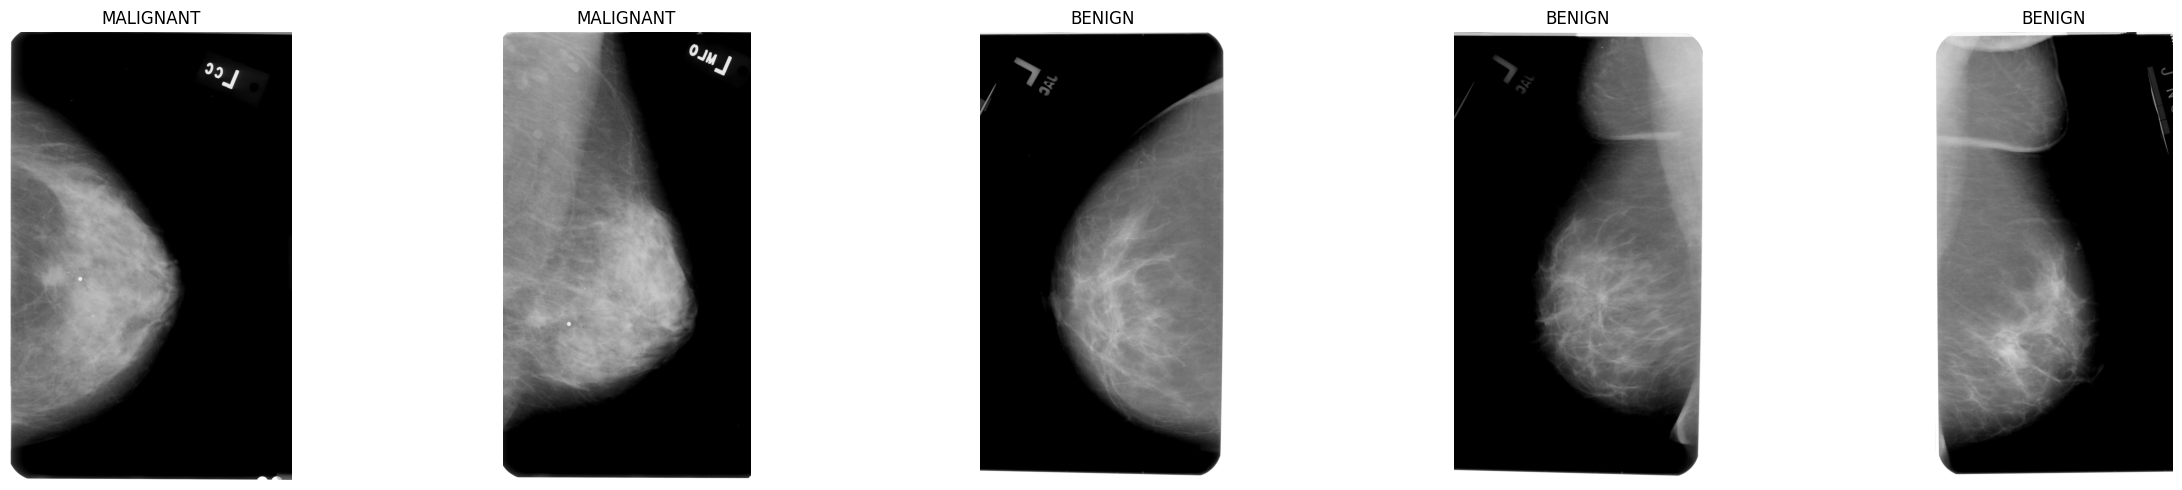

Cropped Mammograms:



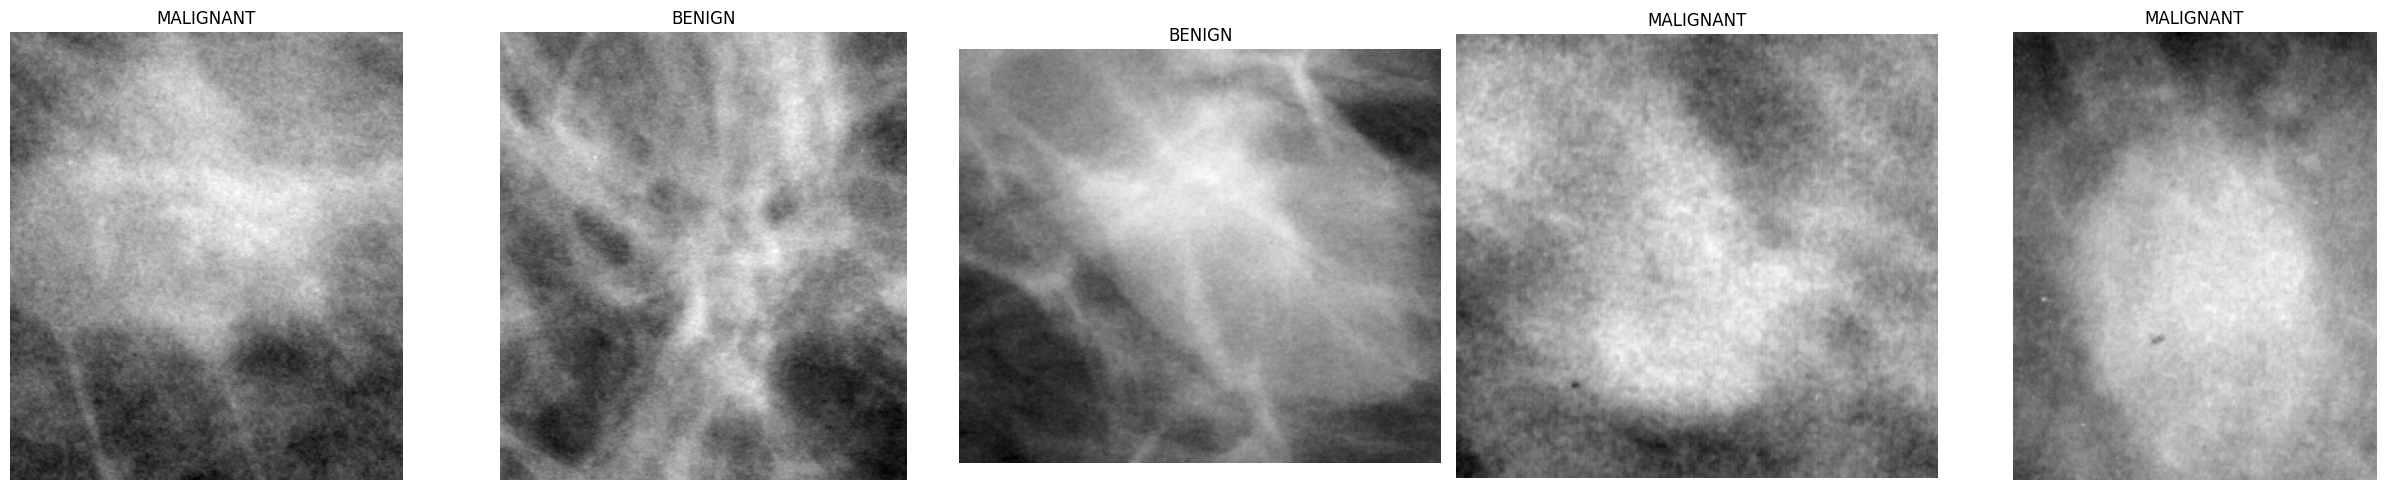

ROI Mask Mammograms:



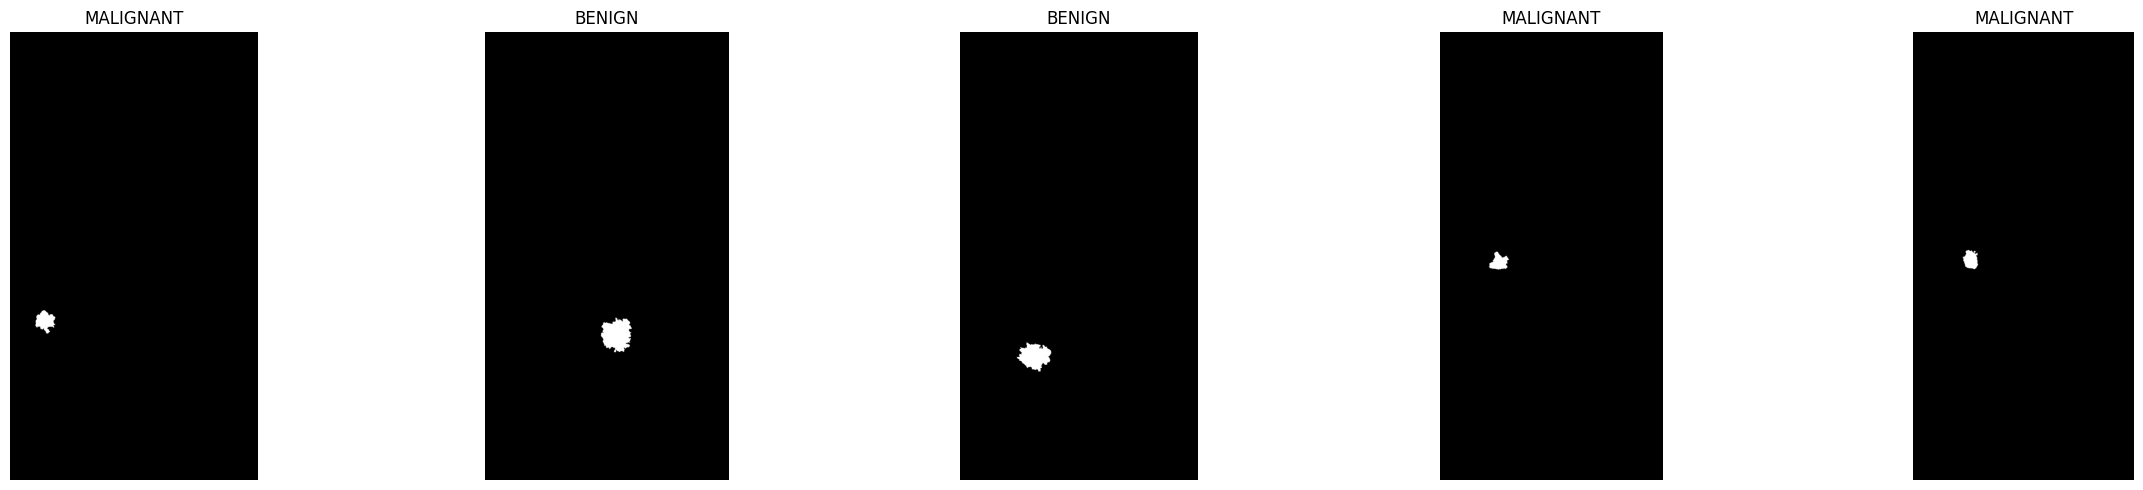

In [51]:
print('Full Mammograms:\n')
display_images('image_file_path', 5)

print('Cropped Mammograms:\n')
display_images('cropped_image_file_path', 5)

print('ROI Mask Mammograms:\n')
display_images('ROI_mask_file_path', 5)


In [52]:
from tensorflow.keras.utils import to_categorical
# Import necessary TensorFlow libraries

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model

# from tensorflow.keras.applications.resnet50 import ResNet50

from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model

from tensorflow.keras.layers import Input, Dense, Dropout
# from tensorflow.keras.applications.densenet import DenseNet169
import keras
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
import warnings

# Suppress all warnings globally
warnings.filterwarnings("ignore")


2025-05-28 18:50:12.336874: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-28 18:50:12.338803: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-28 18:50:12.380955: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-28 18:50:12.381430: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-28 18:50:14.281721: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [53]:
#second preprocessing
def image_processor(image_path, target_size):
    """Preprocess images for CNN model"""
    absolute_image_path = os.path.abspath(image_path)
    #image = cv2.imread(absolute_image_path)
    #image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.imread(absolute_image_path, cv2.IMREAD_GRAYSCALE)

    # Skip unreadable or empty images
    if image is None:
        print(f"Skipping unreadable image: {absolute_image_path}")
        return None
    
    # Resize image
    image = cv2.resize(image, (target_size[1], target_size[0]))
    
    # Histogram Equalization
    #image = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    #l_channel, a_channel, b_channel = cv2.split(image)
    #clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    #l_channel = clahe.apply(l_channel)
    #image = cv2.merge((l_channel, a_channel, b_channel))
    #image = cv2.cvtColor(image, cv2.COLOR_LAB2RGB)
    
     #Negative transformation
    #image = 255 - image
    
     #Rescale to [0, 1]
    image = image.astype(np.float32) / 255.0
    
    return image

In [54]:
# Merge datasets
full_mass = pd.concat([mass_train_df, mass_test_df], axis=0)
full_calc = pd. concat([calc_train_df, calc_test_df], axis=0)

In [55]:
# Define the target size
target_size = (256, 256, 3)

In [56]:
# Sample a subset of images
sample_size = 1696  # Adjust the sample size as needed
full_mass_sample = full_mass.sample(n=sample_size, random_state=42)
full_calc_sample = full_calc.sample(n=sample_size, random_state=42)

In [57]:
full_sample = pd.concat([full_mass_sample, full_calc_sample], axis=0)

In [58]:
print(full_sample.columns)
print(full_sample.head())

Index(['patient_id', 'breast_density', 'left_or_right_breast', 'image_view',
       'abnormality_id', 'abnormality_type', 'mass_shape', 'mass_margins',
       'assessment', 'pathology', 'subtlety', 'image_file_path',
       'cropped_image_file_path', 'ROI_mask_file_path', 'breast density',
       'calc_type', 'calc_distribution'],
      dtype='object')
    patient_id  breast_density left_or_right_breast image_view  \
618    P_00889             3.0                 LEFT        MLO   
115    P_00148             2.0                RIGHT        MLO   
135    P_00199             1.0                 LEFT        MLO   
350    P_00496             3.0                 LEFT         CC   
76     P_00358             4.0                RIGHT         CC   

     abnormality_id abnormality_type                mass_shape  \
618               1             mass                 LOBULATED   
115               1             mass                 IRREGULAR   
135               1             mass              

In [59]:
# Apply preprocessor to train data
full_sample['processed_images'] = full_sample['image_file_path'].apply(
    lambda x: image_processor(x, target_size)
)
full_sample['mask_images'] = full_sample['ROI_mask_file_path'].apply(
    lambda y: image_processor(y, target_size)
)


Skipping unreadable image: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.175476572912204146233170994160170991797/1-227.jpg
Skipping unreadable image: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.199195778912558713817031507321459770006/1-135.jpg


[ WARN:0@69.367] global loadsave.cpp:268 findDecoder imread_('/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.175476572912204146233170994160170991797/1-227.jpg'): can't open/read file: check file path/integrity
[ WARN:0@69.524] global loadsave.cpp:268 findDecoder imread_('/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.199195778912558713817031507321459770006/1-135.jpg'): can't open/read file: check file path/integrity


Skipping unreadable image: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.336120486712406273923832111983569913869/1-113.jpg


[ WARN:0@69.636] global loadsave.cpp:268 findDecoder imread_('/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.336120486712406273923832111983569913869/1-113.jpg'): can't open/read file: check file path/integrity


Skipping unreadable image: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.180869746613853192241744905213634425726/1-281.jpg
Skipping unreadable image: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.235220303613128401917357295780294851812/1-186.jpg
Skipping unreadable image: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.258122848711932114229110145764023097059/1-085.jpg


...

[ WARN:0@204.641] global loadsave.cpp:268 findDecoder imread_('/scratch/xxsi3290/Kaggle/Code/Calc-Test_P_01303_LEFT_CC_1/1.3.6.1.4.1.9590.100.1.2.357371366711708152613945071580006586008/1.3.6.1.4.1.9590.100.1.2.187273540011394482818845349320760063693/000000.dcm'): can't open/read file: check file path/integrity
[ WARN:0@204.641] global loadsave.cpp:268 findDecoder imread_('/scratch/xxsi3290/Kaggle/Code/Calc-Test_P_00495_RIGHT_CC_3/1.3.6.1.4.1.9590.100.1.2.65741421111412931113041998321007691098/1.3.6.1.4.1.9590.100.1.2.348437209511819882819177566002998394324/000000.dcm'): can't open/read file: check file path/integrity
[ WARN:0@204.672] global loadsave.cpp:268 findDecoder imread_('/scratch/xxsi3290/Kaggle/Code/Calc-Test_P_01148_RIGHT_MLO_1/1.3.6.1.4.1.9590.100.1.2.49558796012617217222829933202126547153/1.3.6.1.4.1.9590.100.1.2.213167462112726910607832022314234790605/000000.dcm'): can't open/read file: check file path/integrity
[ WARN:0@204.692] global loadsave.cpp:268 findDecoder imread

Skipping unreadable image: /scratch/xxsi3290/Kaggle/Code/Calc-Test_P_00686_RIGHT_MLO_1/1.3.6.1.4.1.9590.100.1.2.201164804113241891926049606521765088248/1.3.6.1.4.1.9590.100.1.2.6073290111128072308762159373187537346/000000.dcm
Skipping unreadable image: /scratch/xxsi3290/Kaggle/Code/Calc-Test_P_01562_LEFT_MLO_1/1.3.6.1.4.1.9590.100.1.2.178692861610366623407726396720311804352/1.3.6.1.4.1.9590.100.1.2.339524904810678180527824073070691579819/000000.dcm
Skipping unreadable image: /scratch/xxsi3290/Kaggle/Code/Calc-Test_P_01471_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.212009034810432880513231184642328194984/1.3.6.1.4.1.9590.100.1.2.395588043312490852512617634863979223185/000000.dcm
Skipping unreadable image: /scratch/xxsi3290/Kaggle/Code/Calc-Test_P_00570_LEFT_MLO_1/1.3.6.1.4.1.9590.100.1.2.378511752910186124842786656393302488743/1.3.6.1.4.1.9590.100.1.2.370452091713819693735735850443146778984/000000.dcm
Skipping unreadable image: /scratch/xxsi3290/Kaggle/Code/Calc-Test_P_01211_RIGHT_MLO_1/1.3.6.

[ WARN:0@204.865] global loadsave.cpp:268 findDecoder imread_('/scratch/xxsi3290/Kaggle/Code/Calc-Test_P_00686_RIGHT_MLO_1/1.3.6.1.4.1.9590.100.1.2.201164804113241891926049606521765088248/1.3.6.1.4.1.9590.100.1.2.6073290111128072308762159373187537346/000000.dcm'): can't open/read file: check file path/integrity
[ WARN:0@204.880] global loadsave.cpp:268 findDecoder imread_('/scratch/xxsi3290/Kaggle/Code/Calc-Test_P_01562_LEFT_MLO_1/1.3.6.1.4.1.9590.100.1.2.178692861610366623407726396720311804352/1.3.6.1.4.1.9590.100.1.2.339524904810678180527824073070691579819/000000.dcm'): can't open/read file: check file path/integrity
[ WARN:0@204.880] global loadsave.cpp:268 findDecoder imread_('/scratch/xxsi3290/Kaggle/Code/Calc-Test_P_01471_RIGHT_CC_1/1.3.6.1.4.1.9590.100.1.2.212009034810432880513231184642328194984/1.3.6.1.4.1.9590.100.1.2.395588043312490852512617634863979223185/000000.dcm'): can't open/read file: check file path/integrity
[ WARN:0@204.880] global loadsave.cpp:268 findDecoder imrea

Skipping unreadable image: /scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.225473013012007613035899536681936982459/2-165.jpg


[ WARN:0@205.068] global loadsave.cpp:268 findDecoder imread_('/scratch/xxsi3290/Kaggle/jpeg/jpeg/1.3.6.1.4.1.9590.100.1.2.225473013012007613035899536681936982459/2-165.jpg'): can't open/read file: check file path/integrity


In [60]:
# Optionally, remove rows where image processing failed
full_sample = full_sample[full_sample['processed_images'].notnull() & full_sample['mask_images'].notnull()]

In [61]:
full_sample.abnormality_type.unique()

array(['mass', 'calcification'], dtype=object)

In [62]:
# Label each row as micro or macro calcification (only if it's calcification)
full_sample['calc_group'] = full_sample.apply(
    lambda row: 'microcalcification' if row['abnormality_type'] == 'calcification' and row['calc_distribution'] in micro_list
    else ('macrocalcification' if row['abnormality_type'] == 'calcification' else None),
    axis=1
)

# Map to classes
def map_class(row):
    abnormality = row.get('abnormality_type')
    pathology = row.get('pathology')
    calc_group = row.get('calc_group')

    if pathology == 'BENIGN_WITHOUT_CALLBACK':
        return 'Normal'
    elif abnormality == 'mass' and pathology == 'BENIGN':
        return 'Mass & Benign'
    elif abnormality == 'mass' and pathology == 'MALIGNANT':
        return 'Mass & Malignant'
    elif calc_group == 'microcalcification' and pathology == 'BENIGN':
        return 'Microcalcification & Benign'
    elif calc_group == 'microcalcification' and pathology == 'MALIGNANT':
        return 'Microcalcification & Malignant'
    elif calc_group == 'macrocalcification' and pathology == 'BENIGN':
        return 'Macrocalcification & Benign'
    elif calc_group == 'macrocalcification' and pathology == 'MALIGNANT':
        return 'Macrocalcification & Malignant'
    else:
        return -1  # Unknown class

# Apply mapping
full_sample['class'] = full_sample.apply(map_class, axis=1)
full_sample['class'] = full_sample['class'].astype(str)

In [63]:
print(full_sample['class'].value_counts().sort_index())

class
Macrocalcification & Benign        15
Macrocalcification & Malignant     24
Mass & Benign                     515
Mass & Malignant                  496
Microcalcification & Benign       305
Microcalcification & Malignant    304
Normal                            344
Name: count, dtype: int64


In [64]:
# Convert the processed_images column to an array
X_resized = np.array(full_sample['processed_images'].tolist())
print(X_resized.shape)

(2003, 256, 256)


In [65]:
# Check the number of classes
num_classes = len(full_sample['class'].unique())
num_classes

7

In [66]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_resized, full_sample['class'].values, test_size=0.3, random_state=42)

In [67]:
dataset_path = '/scratch/xxsi3290/Kaggle/jpeg/jpeg/'
BATCH_SIZE = 32

In [68]:
# Data_augmentation
train_datagen = ImageDataGenerator(rotation_range=20,
                                   rescale=1.0 / 255,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   vertical_flip=True,
                                   fill_mode='nearest')

# Flow from DataFrame
train_generator = train_datagen.flow_from_dataframe(
    dataframe=full_sample,
    x_col='image_file_path',
    y_col='class',
    target_size=(256, 256),
    batch_size=32,
    class_mode='categorical',  # for multi-class classification
    subset='training',
    shuffle=True,
    seed=42
)

Found 2003 validated image filenames belonging to 7 classes.


In [69]:
X_train = np.expand_dims(X_train, axis=-1)  # (N, 224, 224, 1)
X_train = np.repeat(X_train, 3, axis=-1)    # (N, 224, 224, 3)

X_test = np.expand_dims(X_test, axis=-1)
X_test = np.repeat(X_test, 3, axis=-1)

In [70]:
# Print shapes for verification
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (1402, 256, 256, 3)
X_test shape: (601, 256, 256, 3)
y_train shape: (1402,)
y_test shape: (601,)


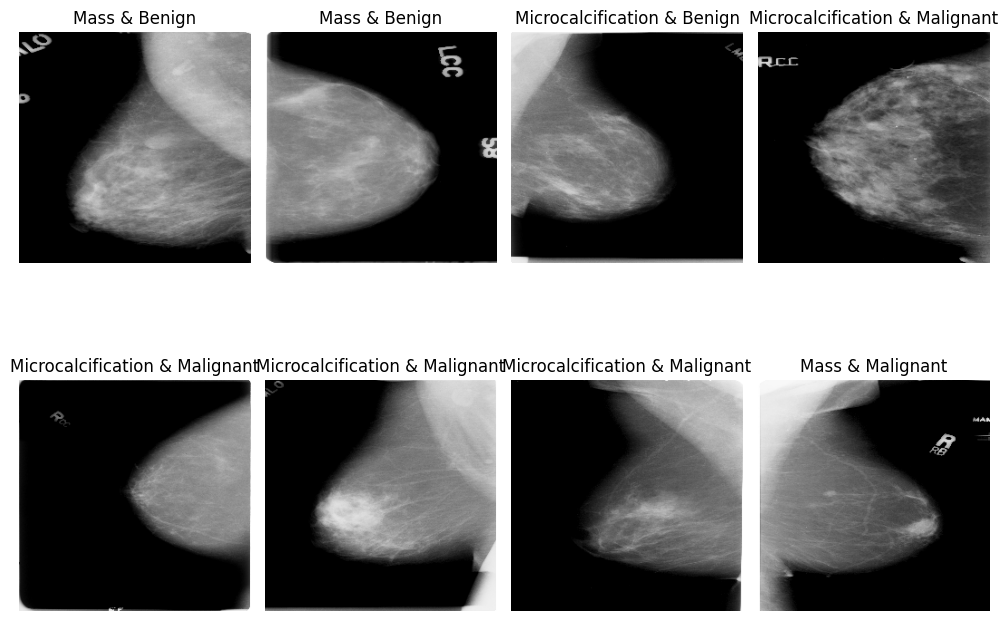

In [71]:
def display_images(images, titles, rows, cols, figsize=(10, 8)):
    """Display a grid of images with titles"""
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        ax.set_title(titles[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Select a sample
sample_images = X_train[:8]
sample_labels = y_train[:8]  # Convert one-hot to class index

# Titles
class_names = ['BENIGN_WITHOUT_CALLBACK', 'MASS & MALIGNANT', 'MASS & BENIGN', 'CALC & MALIGNANT', 'CALC & BENIGN']
image_titles = sample_labels

# Display
display_images(sample_images, image_titles, 2, 4)

In [72]:
labels = {value: key for key, value in train_generator.class_indices.items()}

print("Label Mappings for classes present in the training and validation datasets\n")
for key, value in labels.items():
    print(f"{key} : {value}")

Label Mappings for classes present in the training and validation datasets

0 : Macrocalcification & Benign
1 : Macrocalcification & Malignant
2 : Mass & Benign
3 : Mass & Malignant
4 : Microcalcification & Benign
5 : Microcalcification & Malignant
6 : Normal


In [73]:
from keras.models import Model
from keras.layers import Input, GlobalAveragePooling2D, Dense
from keras.optimizers import Adam
from keras.callbacks import LearningRateScheduler
from keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np
from keras.regularizers import l2
from tensorflow.keras.applications import InceptionV3
import cv2
from skimage.filters import threshold_otsu
from skimage.restoration import wiener
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.losses import CategoricalCrossentropy
from skimage import exposure
from skimage.restoration import wiener
from skimage.morphology import disk
#import pywt
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
# Load pre-trained InceptionV3 model
base_model = InceptionV3(weights='imagenet', include_top=False)

2025-05-28 18:52:37.354123: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [75]:
from keras.layers import GlobalAveragePooling2D, Dense, Dropout
from keras.regularizers import l1_l2

In [76]:
# Define regularization parameters
l1_reg = 0.001
l2_reg = 0.001
dropout_rate = 0.3

# Add new classification layers with regularization
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu', kernel_regularizer=l1_l2(l1=l1_reg, l2=l2_reg))(x)
x = Dropout(dropout_rate)(x)  # Dropout layer to prevent overfitting
predictions = Dense(7, activation='softmax')(x)

# Combine base model with new classification layers
model = Model(inputs=base_model.input, outputs=predictions, name="InceptionV3")

In [77]:
model.summary()

Model: "InceptionV3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, None, None, 3)]      0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, None, None, 32)       864       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, None, None, 32)       96        ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, None, None, 32)       0         ['batch_normalizatio

In [78]:
#Adam
# Compile the model with initial learning rate
initial_learning_rate = 0.0001
model.compile(optimizer=Adam(learning_rate=initial_learning_rate), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

In [79]:
# Define a learning rate scheduler (if needed)
def lr_schedule(epoch):
    # Learning Rate Schedule
    lr = initial_learning_rate
    if epoch > 10:
        lr *= 0.1
    elif epoch > 5:
        lr *= 0.5
    return lr

In [80]:
from keras.callbacks import EarlyStopping

In [81]:
from keras.callbacks import ModelCheckpoint

# Define the checkpoint directory and file name
checkpoint_filepath = 'path/to/your/checkpoint_directory/model_InceptionV3_Mass&Calc-{epoch:02d}-{val_accuracy:.2f}.weights.h5'

# Create a ModelCheckpoint callback
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [82]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# Step 1: Encode string labels to integers
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_test_int = label_encoder.transform(y_test)

# Step 2: Convert to one-hot encoding
y_train_encoded = to_categorical(y_train_int)
y_test_encoded = to_categorical(y_test_int)

# Optional: Check label mapping
label_map = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label mapping:")
for k, v in label_map.items():
    print(f"{v}: {k}")

Label mapping:
0: Macrocalcification & Benign
1: Macrocalcification & Malignant
2: Mass & Benign
3: Mass & Malignant
4: Microcalcification & Benign
5: Microcalcification & Malignant
6: Normal


In [84]:
import numpy as np
from sklearn.utils import class_weight

# Convert one-hot encoded y_train to integer labels
y_train_int = np.argmax(y_train_encoded, axis=1)

# Compute class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Convert to dictionary format expected by Keras
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

print("✅ Class weights:", class_weights_dict)

✅ Class weights: {0: 18.207792207792206, 1: 16.69047619047619, 2: 0.5771922601893783, 3: 0.5755336617405583, 4: 0.944743935309973, 5: 0.9359145527369827, 6: 0.7763012181616833}


In [85]:
# Define early stopping criteria
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Define training parameters
batch_size = 20
max_epochs = 100
num_iterations = 100

# Train the model with early stopping
#history = model.fit(X_train, y_train,
 #                   batch_size=batch_size,
  #                  epochs=max_epochs,
   #                 steps_per_epoch=num_iterations,
    #                validation_data=(X_test, y_test), 
     #               callbacks=[LearningRateScheduler(lr_schedule), early_stopping])


# Now, include the callback in your model.fit() call
history = model.fit(X_train, y_train_encoded,
                    batch_size=batch_size,
                    epochs=max_epochs,
                    class_weight=class_weights_dict, 
                    steps_per_epoch=num_iterations,
                    validation_data=(X_test, y_test_encoded),
                    callbacks=[LearningRateScheduler(lr_schedule), early_stopping, model_checkpoint_callback])


Epoch 1/100
100/100 [==============================] - ETA: 0s - loss: 45.9202 - accuracy: 0.2074
Epoch 1: val_loss improved from -inf to 42.16766, saving model to path/to/your/checkpoint_directory/model_InceptionV3_Mass&Calc-01-0.31.weights.h5
100/100 [==============================] - 45s 319ms/step - loss: 45.9202 - accuracy: 0.2074 - val_loss: 42.1677 - val_accuracy: 0.3062 - lr: 1.0000e-04
Epoch 2/100
100/100 [==============================] - ETA: 0s - loss: 38.6690 - accuracy: 0.3875
Epoch 2: val_loss did not improve from 42.16766
100/100 [==============================] - 28s 277ms/step - loss: 38.6690 - accuracy: 0.3875 - val_loss: 36.0864 - val_accuracy: 0.2313 - lr: 1.0000e-04
Epoch 3/100
100/100 [==============================] - ETA: 0s - loss: 33.0362 - accuracy: 0.4078
Epoch 3: val_loss did not improve from 42.16766
100/100 [==============================] - 28s 277ms/step - loss: 33.0362 - accuracy: 0.4078 - val_loss: 31.1056 - val_accuracy: 0.2962 - lr: 1.0000e-04
Epoc

In [86]:
# Get validation history
val_loss = history.history['val_loss']
val_accuracy = history.history['val_accuracy']

In [87]:
# Get training history
train_loss = history.history['loss']
train_accuracy = history.history['accuracy']

In [88]:
# Calculate overall training and validation loss and accuracy
overall_train_loss = np.mean(train_loss)
overall_train_accuracy = np.mean(train_accuracy)
overall_val_loss = np.mean(val_loss)
overall_val_accuracy = np.mean(val_accuracy)

# Print the overall accuracy
print("Overall Training Accuracy:", overall_train_accuracy)
print("Overall Validation Accuracy:", overall_val_accuracy)

Overall Training Accuracy: 0.9331983872171905
Overall Validation Accuracy: 0.43293583475881153


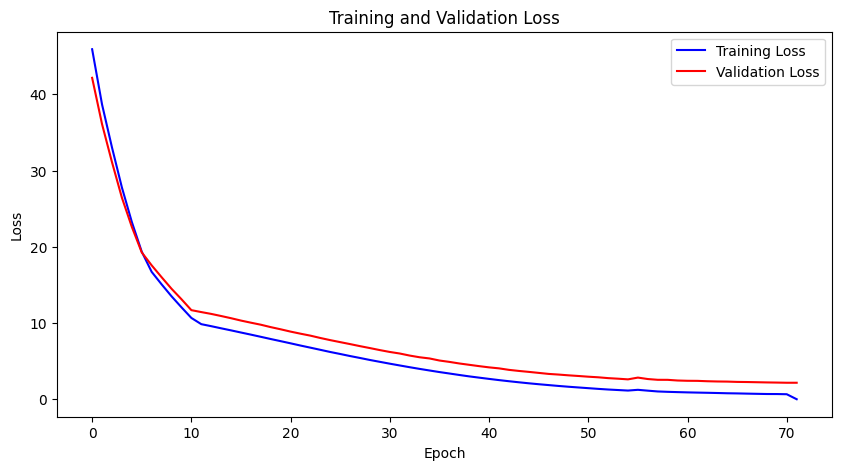

In [89]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='red')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

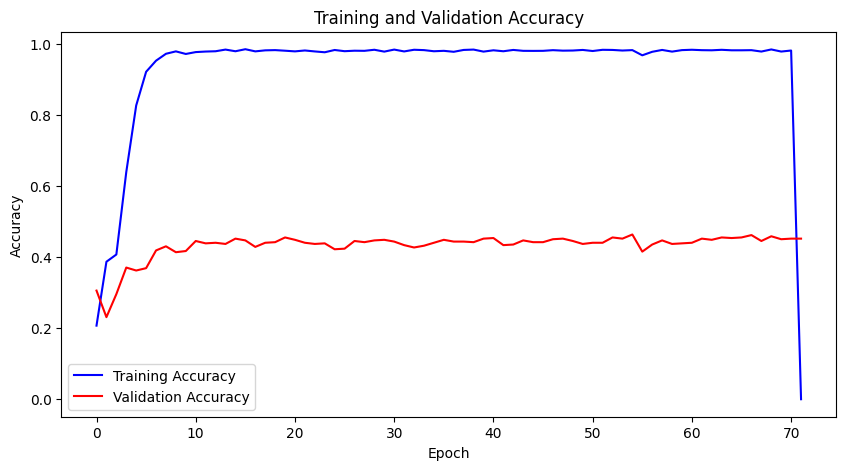

In [90]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(train_accuracy, label='Training Accuracy', color='blue')
plt.plot(val_accuracy, label='Validation Accuracy', color='red')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [94]:
#'MALIGNANT': 1, 'BENIGN': 0, 'BENIGN_WITHOUT_CALLBACK': 0 , 
# Define label_to_class mapping
label_to_class = {
   0 : 'Macrocalcification & Benign',
   1 : 'Macrocalcification & Malignant',
   2 : 'Mass & Benign',
   3 : 'Mass & Malignant',
   4 : 'Microcalcification & Benign',
   5 : 'Microcalcification & Malignant',
   6 : 'Normal'
    # Add more mappings as needed
}

# Function to decode predictions
def decode_predictions(predictions, threshold=0.5):
    decoded_labels = []
    for pred in predictions:
        decoded_labels.append([label_to_class[i] for i, p in enumerate(pred) if p >= threshold])
    return decoded_labels

1/1 [==============================] - 0s 38ms/step
True Class: Mass & Malignant
Predicted Class: [['Mass & Malignant']]


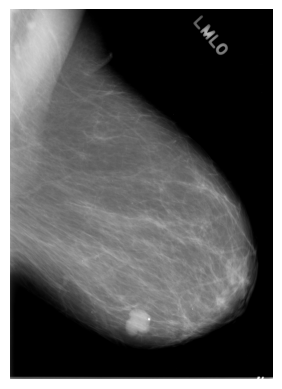

1/1 [==============================] - 0s 37ms/step
True Class: Mass & Benign
Predicted Class: [['Mass & Benign']]


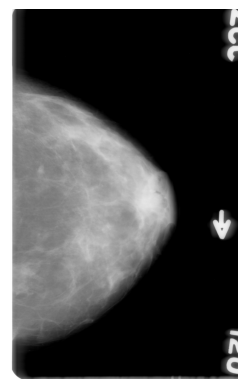

1/1 [==============================] - 0s 37ms/step
True Class: Mass & Benign
Predicted Class: [['Mass & Benign']]


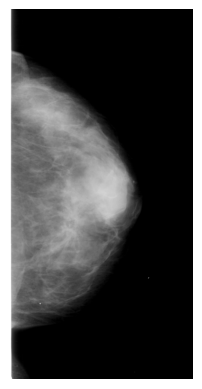

1/1 [==============================] - 0s 38ms/step
True Class: Mass & Benign
Predicted Class: [['Mass & Benign']]


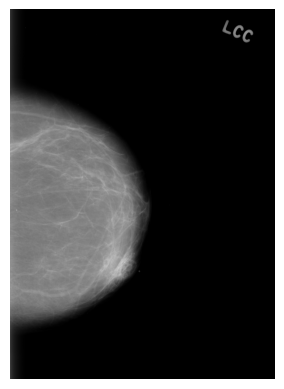

1/1 [==============================] - 0s 37ms/step
True Class: Mass & Malignant
Predicted Class: [['Mass & Malignant']]


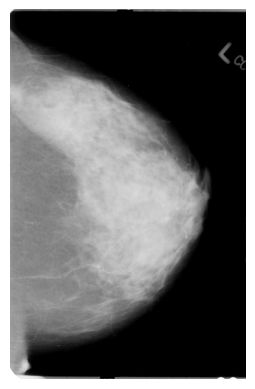

1/1 [==============================] - 0s 37ms/step
True Class: Mass & Malignant
Predicted Class: [['Mass & Malignant']]


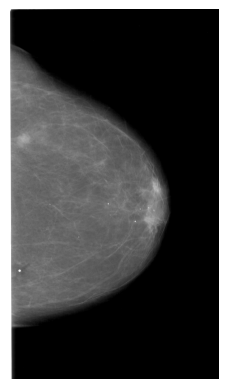

1/1 [==============================] - 0s 37ms/step
True Class: Mass & Benign
Predicted Class: [['Mass & Benign']]


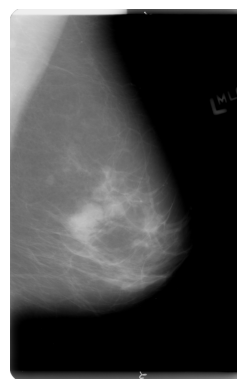

1/1 [==============================] - 0s 38ms/step
True Class: Mass & Malignant
Predicted Class: [['Mass & Malignant']]


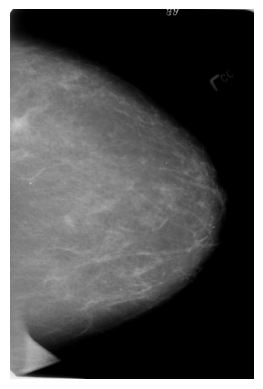

1/1 [==============================] - 0s 37ms/step
True Class: Mass & Benign
Predicted Class: [['Mass & Benign']]


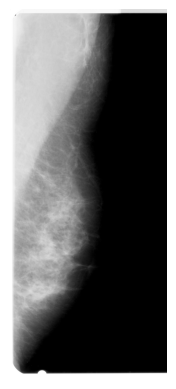

In [95]:
# Function to preprocess and load image
def preprocess_image(image_path):
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # Resize image to match model's input shape
    img = cv2.resize(img, (224, 224))
    # Normalize pixel values
    img = img.astype(np.float32) / 255.0
    # Convert to RGB color mode
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img

# Select the first 5 images from mass_test_combined
test_images = full_sample['image_file_path'].iloc[1:10]
true_classes = full_sample['class'].iloc[1:10]
mapped_true_classes = full_sample.iloc[1:10].apply(map_class, axis=1) 

# Predict classes for each image
for image_path, true_class in zip(test_images, mapped_true_classes):
    # Preprocess image
    img = preprocess_image(image_path)
    # Make prediction
    pred = model.predict(np.array([img]))
    predictions = decode_predictions(pred)
    # Print true and predicted classes
    print("True Class:", true_class)
    print("Predicted Class:", predictions)
    # Load and display the image
    image = mpimg.imread(image_path)
    plt.imshow(image, cmap='gray')
    plt.axis('off')
    plt.show()

In [96]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
import seaborn as sns

In [97]:
datasets = {
    "Training": (X_train, y_train_encoded),
    "Test": (X_test, y_test_encoded)
}


In [98]:
from sklearn.preprocessing import LabelEncoder

# Create and fit encoder
label_encoder = LabelEncoder()
label_encoder.fit(y_train)  # Fit using ALL labels

# Transform labels
y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Save class names for later
class_names = label_encoder.classes_


In [99]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate_model(model, datasets, class_names):
    all_metrics = {}
    all_confusion_matrices = {}

    for dataset_type, (X_data, y_true) in datasets.items():
        y_pred = model.predict(X_data)
        y_pred_labels = np.argmax(y_pred, axis=1)

        # 🔧 Fix: Convert one-hot y_true to class indices
        if len(y_true.shape) > 1 and y_true.shape[1] > 1:
            y_true = np.argmax(y_true, axis=1)

        # Compute metrics
        accuracy = accuracy_score(y_true, y_pred_labels)
        recall = recall_score(y_true, y_pred_labels, average='weighted')
        precision = precision_score(y_true, y_pred_labels, average='weighted')
        f1 = f1_score(y_true, y_pred_labels, average='weighted')
        confusion_mat = confusion_matrix(y_true, y_pred_labels)

        # Save results
        all_metrics[dataset_type] = {
            'accuracy': accuracy,
            'recall': recall,
            'precision': precision,
            'f1': f1
        }
        all_confusion_matrices[dataset_type] = confusion_mat

        # Print report
        print(f"\n{dataset_type} Classification Report:")
        print(classification_report(y_true, y_pred_labels, target_names=class_names))

        # Plot confusion matrix
        plt.figure(figsize=(8, 6))
        sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"{dataset_type} Confusion Matrix")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.show()

    # Calculate overall confusion matrix
    overall_confusion_matrix = sum(all_confusion_matrices.values())
    all_confusion_matrices["Overall"] = overall_confusion_matrix

    # Print and plot overall
    print("\nOverall Confusion Matrix:")
    plt.figure(figsize=(8, 6))
    sns.heatmap(overall_confusion_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Overall Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    # Print averaged metrics
    print("\nOverall Performance (Average Across Datasets):")
    for metric in ['accuracy', 'recall', 'precision', 'f1']:
        avg_score = np.mean([m[metric] for m in all_metrics.values()])
        print(f"{metric}: {avg_score:.4f}")

    return all_metrics, all_confusion_matrices


44/44 [==============================] - 5s 91ms/step

Training Classification Report:
                                precision    recall  f1-score   support

   Macrocalcification & Benign       0.92      1.00      0.96        11
Macrocalcification & Malignant       1.00      1.00      1.00        12
                 Mass & Benign       1.00      0.98      0.99       347
              Mass & Malignant       1.00      0.98      0.99       348
   Microcalcification & Benign       0.98      1.00      0.99       212
Microcalcification & Malignant       0.94      1.00      0.97       214
                        Normal       1.00      0.99      0.99       258

                      accuracy                           0.99      1402
                     macro avg       0.98      0.99      0.98      1402
                  weighted avg       0.99      0.99      0.99      1402



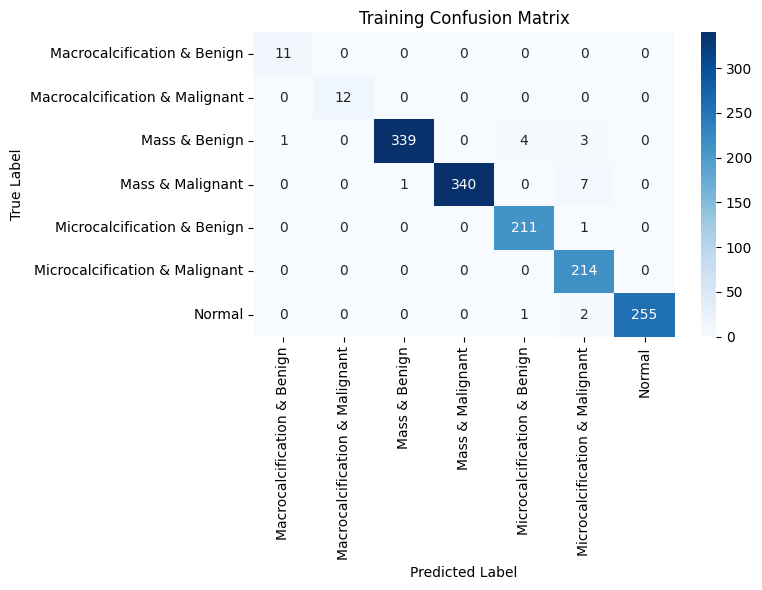

19/19 [==============================] - 2s 89ms/step

Test Classification Report:
                                precision    recall  f1-score   support

   Macrocalcification & Benign       0.33      0.25      0.29         4
Macrocalcification & Malignant       0.17      0.08      0.11        12
                 Mass & Benign       0.48      0.53      0.50       168
              Mass & Malignant       0.44      0.41      0.43       148
   Microcalcification & Benign       0.33      0.29      0.31        93
Microcalcification & Malignant       0.34      0.30      0.32        90
                        Normal       0.62      0.77      0.69        86

                      accuracy                           0.45       601
                     macro avg       0.39      0.38      0.38       601
                  weighted avg       0.44      0.45      0.44       601



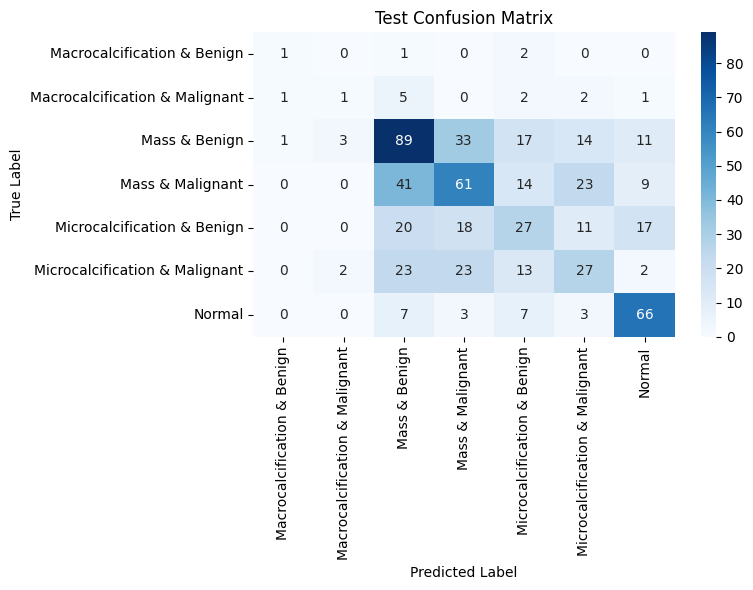


Overall Confusion Matrix:


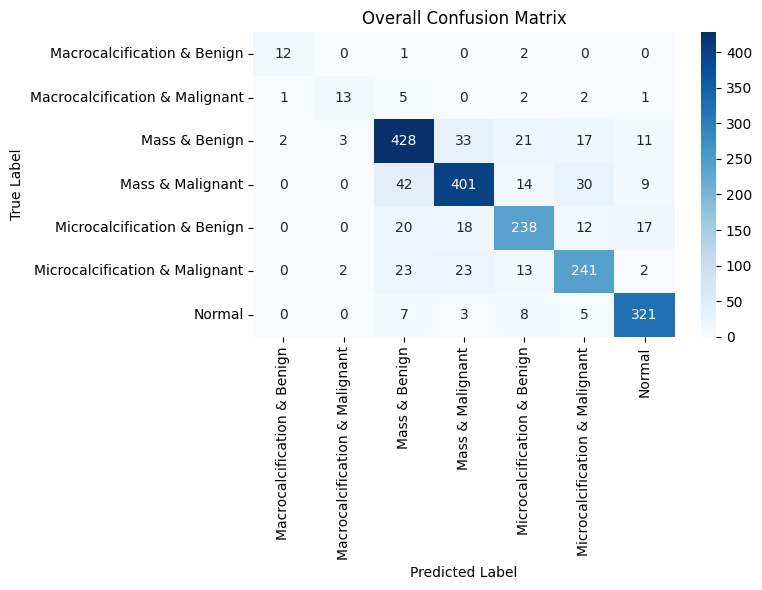


Overall Performance (Average Across Datasets):
accuracy: 0.7192
recall: 0.7192
precision: 0.7126
f1: 0.7146


In [100]:
all_metrics, all_confusion_matrices = evaluate_model(model, datasets, class_names)

In [101]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import matplotlib.image as mpimg
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

def show_predictions(X_test, y_test_masks, model, history, num=1):
    """Function to process test images, save results and plot training history"""
    # Define the output directory for saving images and plots
    parent_dir = os.path.abspath("/scratch/xxsi3290/Kaggle/Segmentation_results")
    file_time = time.strftime('%Y%m%d_%H%M%S')
    output_directory = os.path.join(parent_dir, f"{file_time}_new_UNET_Segmentation")

    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
        print(f"Created directory: {output_directory}")
    else:
        print(f"Saving to existing directory: {output_directory}")

    return output_directory

# Plot and save loss & accuracy
def save_training_history_plots(history, output_directory):
    val_loss = history.history['val_loss']
    val_accuracy = history.history['val_accuracy']
    train_loss = history.history['loss']
    train_accuracy = history.history['accuracy']

    # Plot and save loss
    plt.figure(figsize=(10, 5))
    plt.plot(train_loss, label='Training Loss', color='blue')
    plt.plot(val_loss, label='Validation Loss', color='red')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, 'loss_plot.png'))
    plt.close()

    # Plot and save accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(train_accuracy, label='Training Accuracy', color='blue')
    plt.plot(val_accuracy, label='Validation Accuracy', color='red')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, 'accuracy_plot.png'))
    plt.close()

def save_confusion_and_report(model, datasets, output_directory):
    all_confusion = {}

    for dataset_type, (X_data, y_true) in datasets.items():
        y_pred = model.predict(X_data)
        y_pred_labels = np.argmax(y_pred, axis=1)
        
        if len(y_true.shape) > 1:
            y_true = np.argmax(y_true, axis=1)

        # Automatically get unique class names based on y_true
        le = LabelEncoder()
        le.fit(y_true)
        class_names = label_encoder.classes_

        conf_mat = confusion_matrix(y_true, y_pred_labels)

        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"{dataset_type} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.savefig(os.path.join(output_directory, f"{dataset_type.lower()}_confusion_matrix.png"))
        plt.close()

        report = classification_report(y_true, y_pred_labels, target_names=class_names)
        with open(os.path.join(output_directory, f"{dataset_type.lower()}_classification_report.txt"), 'w') as f:
            f.write(report)

        all_confusion[dataset_type] = conf_mat

    return all_confusion



def save_prediction_images(test_images, mapped_true_classes, model, output_directory):
    for idx, (image_path, true_class) in enumerate(zip(test_images, mapped_true_classes)):
        image = mpimg.imread(image_path)
        img = preprocess_image(image_path)
        pred = model.predict(np.array([img]), verbose=0)
        predictions = decode_predictions(pred)

        plt.figure(figsize=(5, 5))
        plt.imshow(image, cmap='gray')
        plt.axis('off')
        plt.title(f"True: {true_class}\nPredicted: {predictions[0]}")
        
        save_path = os.path.join(output_directory, f"prediction_{idx+1}.png")
        plt.savefig(save_path, bbox_inches='tight')
        plt.close()


# === MAIN EXECUTION ===
output_dir = show_predictions(X_test, y_test_encoded, model, history)

save_training_history_plots(history, output_dir)
save_confusion_and_report(model, datasets, output_dir)
save_prediction_images(test_images, mapped_true_classes, model, output_dir)

print(f"All results saved in: {output_dir}")


Created directory: /scratch/xxsi3290/Kaggle/Segmentation_results/20250530_101007_new_UNET_Segmentation
19/19 [==============================] - 2s 86ms/step
All results saved in: /scratch/xxsi3290/Kaggle/Segmentation_results/20250530_101007_new_UNET_Segmentation


In [102]:
import os
import json
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report

# --- Helper function to preprocess a single image ---
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224, 224))
    img = img.astype(np.float32) / 255.0
    img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img

# --- Main evaluation function ---
def evaluate_model(model, datasets, class_names, full_sample=None, map_class=None, decode_predictions=None, save_dir='evaluation_results'):
    os.makedirs(save_dir, exist_ok=True)  # Create folder if not exist

    all_metrics = {}
    all_confusion_matrices = {}

    for dataset_type, (X_data, y_true) in datasets.items():
        y_pred = model.predict(X_data)
        y_pred_labels = np.argmax(y_pred, axis=1)

        # Compute metrics
        accuracy = accuracy_score(y_true, y_pred_labels)
        recall = recall_score(y_true, y_pred_labels, average='weighted')
        precision = precision_score(y_true, y_pred_labels, average='weighted')
        f1 = f1_score(y_true, y_pred_labels, average='weighted')
        confusion_mat = confusion_matrix(y_true, y_pred_labels)

        # Save metrics
        all_metrics[dataset_type] = {
            'accuracy': accuracy,
            'recall': recall,
            'precision': precision,
            'f1': f1
        }
        all_confusion_matrices[dataset_type] = confusion_mat

        # Save classification report
        report_str = classification_report(y_true, y_pred_labels, target_names=class_names)
        with open(os.path.join(save_dir, f"{dataset_type}_classification_report.txt"), "w") as f:
            f.write(report_str)

        # Save confusion matrix plot
        plt.figure(figsize=(8, 6))
        sns.heatmap(confusion_mat, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"{dataset_type} Confusion Matrix")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"{dataset_type}_confusion_matrix.png"))
        plt.close()

    # --- Save overall confusion matrix ---
    overall_confusion_matrix = sum(all_confusion_matrices.values())
    all_confusion_matrices["Overall"] = overall_confusion_matrix

    plt.figure(figsize=(8, 6))
    sns.heatmap(overall_confusion_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Overall Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "Overall_confusion_matrix.png"))
    plt.close()

    # --- Save average metrics ---
    avg_metrics = {}
    for metric in ['accuracy', 'recall', 'precision', 'f1']:
        avg_score = np.mean([m[metric] for m in all_metrics.values()])
        avg_metrics[metric] = avg_score

    with open(os.path.join(save_dir, "average_metrics.json"), "w") as f:
        json.dump(avg_metrics, f, indent=4)

    with open(os.path.join(save_dir, "all_metrics.json"), "w") as f:
        json.dump(all_metrics, f, indent=4)

    # --- Optional: Save predictions for a few images from full_sample ---
    if full_sample is not None and map_class is not None and decode_predictions is not None:
        sample_dir = os.path.join(save_dir, 'sample_predictions')
        os.makedirs(sample_dir, exist_ok=True)

        test_images = full_sample['image_file_path'].iloc[1:10]
        true_classes = full_sample['class'].iloc[1:10]
        mapped_true_classes = full_sample.iloc[1:10].apply(map_class, axis=1)

        for i, (image_path, true_class) in enumerate(zip(test_images, mapped_true_classes)):
            img = preprocess_image(image_path)
            pred = model.predict(np.array([img]))
            predictions = decode_predictions(pred)
            predicted_label = predictions[0][0][1]  # Adjust depending on decode_predictions output

            image = mpimg.imread(image_path)
            plt.imshow(image, cmap='gray')
            plt.title(f"True: {true_class} | Pred: {predicted_label}")
            plt.axis('off')
            plt.tight_layout()
            plt.savefig(os.path.join(sample_dir, f"sample_{i+1}.png"))
            plt.close()

    print(f"All evaluation results saved to '{save_dir}/'")
    return all_metrics, all_confusion_matrices
